In [1]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.21.0


In [2]:
data_dir = Path("../data/raw/flowers")
img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)
print("num_classes:", num_classes)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
num_classes: 5


In [3]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

normalize = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (augment(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalize(x), y))
val_ds = val_ds.map(lambda x, y: (normalize(x), y))

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

In [4]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels[:10].numpy())

(32, 224, 224, 3)
[0 0 4 4 1 3 3 0 4 0]


In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
base_model.trainable = False

print(base_model.output_shape)
print("Trainable vars:", len(base_model.trainable_variables))

(None, 7, 7, 2048)
Trainable vars: 0


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

efficient_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
efficient_base.trainable = False

print(efficient_base.output_shape)
print("Trainable vars:", len(efficient_base.trainable_variables))

14319616/16705208 ━━━━━━━━━━━━━━━━━━━━ 9s 4us/step

KeyboardInterrupt: 

### Build and Compile the Model

The model uses a frozen `ResNet50` backbone with a small classification head.

In [ ]:
from tensorflow.keras import models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,989 (92.14 MB)

 Trainable params: 562,181 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### Train the Classification Head

Train the new head while the backbone stays frozen.

In [ ]:
epochs = 10

history = model.fit(
    train_ds,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=val_ds
)


Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 97s 741ms/step - accuracy: 0.3836 - loss: 1.5026 - val_accuracy: 0.2375 - val_loss: 1.5968
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.4629 - loss: 1.3508 - val_accuracy: 0.2769 - val_loss: 1.5144
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.5052 - loss: 1.2569 - val_accuracy: 0.4311 - val_loss: 1.4010
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.5321 - loss: 1.1886 - val_accuracy: 0.5075 - val_loss: 1.2676
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.5452 - loss: 1.1514 - val_accuracy: 0.5353 - val_loss: 1.1800
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.5732 - loss: 1.1094 - val_accuracy: 0.5400 - val_loss: 1.1319
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.6008 - loss: 1.0723 - val_accuracy: 0.5481 - val_loss: 1.1338
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.6048 - loss: 1.0087 -

### Fine-tuning

Unfreeze the backbone and continue training with a lower learning rate.

In [ ]:
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,989 (92.14 MB)

 Trainable params: 24,096,773 (91.92 MB)

 Non-trainable params: 57,216 (223.50 KB)

Now, train the fine-tuned model for a few more epochs.

### Evaluate the Model

Evaluate the model on the validation set.

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.5516 - loss: 1.1681
Validation Loss: 1.1681
Validation Accuracy: 0.5516
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━

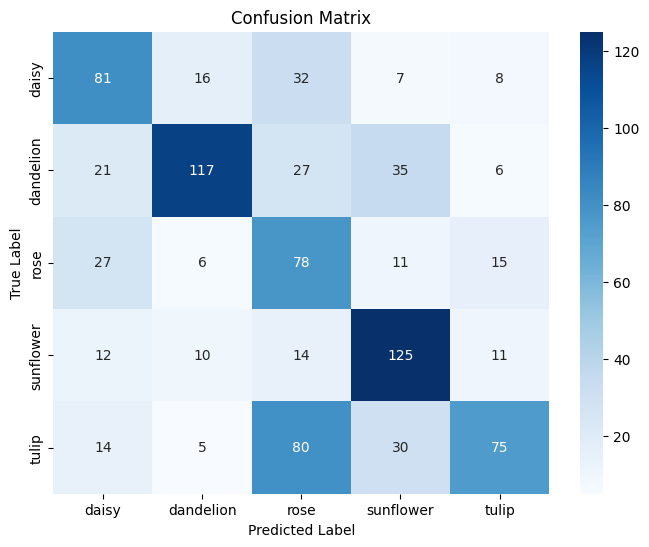

Classification Report:
              precision    recall  f1-score   support

       daisy       0.52      0.56      0.54       144
   dandelion       0.76      0.57      0.65       206
        rose       0.34      0.57      0.42       137
   sunflower       0.60      0.73      0.66       172
       tulip       0.65      0.37      0.47       204

    accuracy                           0.55       863
   macro avg       0.57      0.56      0.55       863
weighted avg       0.60      0.55      0.56       863



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

val_labels = []
val_predictions = []

for images, labels in val_ds:
    val_labels.extend(labels.numpy())
    preds = model.predict(images)
    val_predictions.extend(np.argmax(preds, axis=1))

val_labels = np.array(val_labels)
val_predictions = np.array(val_predictions)

cm = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(val_labels, val_predictions, target_names=class_names)
print("Classification Report:")
print(report)


### Save the Model

Save the model and class mapping for later use.

In [ ]:
import json

model_save_path = Path("../models/flower_classifier_model.keras")

model.save(model_save_path)
print(f"Model saved to {model_save_path}")

class_to_index = {name: i for i, name in enumerate(class_names)}
with open(Path('../models/class_names.json'), 'w') as f:
    json.dump(class_to_index, f)
print("Class names mapping saved to models/class_names.json")


Model saved to ../models/flower_classifier_model.keras
Class names mapping saved to ../models/class_names.json
